In [ ]:
!pip install flask

In [ ]:
#title Loading in our data and importing necessary packages
import numpy as np
import pandas as pd
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import confusion_matrix
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import f1_score

from numpy import expand_dims
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense, Dropout, Reshape, BatchNormalization
from keras.metrics import Precision, Recall
from sklearn.metrics import f1_score
from tensorflow.keras.optimizers import RMSprop
import tensorflow as tf
import albumentations as A
from flask import Flask

In [ ]:
import tensorflow as tf

# 1. Load your existing pre-trained Keras Sequential model
model = tf.keras.models.load_model('my_cnn_model.h5')

# 2. Initialize the TFLite Converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optional: Apply quantization to make the model smaller & faster on mobile
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 3. Convert the model
tflite_model = converter.convert()

# 4. Save the optimized mobile file
with open('my_model.tflite', 'wb') as f:
    f.write(tflite_model)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'my_cnn_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
'''
#@title attempting to download more monarch butterfly images for the dataset
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="uf61JGUNZFfJdZAqxbRe")
project = rf.workspace("ajay-goverdhan-yrdzv").project("monarch-butterfly-classification-uh0un")
version = project.version(1)
dataset = version.download("folder")
'''

'\n#@title attempting to download more monarch butterfly images for the dataset\n!pip install roboflow\n\nfrom roboflow import Roboflow\nrf = Roboflow(api_key="uf61JGUNZFfJdZAqxbRe")\nproject = rf.workspace("ajay-goverdhan-yrdzv").project("monarch-butterfly-classification-uh0un")\nversion = project.version(1)\ndataset = version.download("folder")\n'

In [ ]:
#print(dataset)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#butterfly_data = np.load("train.zip")

'''
df = pd.read_csv("Training_set.csv")
df.columns
df = df.iloc[:3000]
'''
#csv_file = '/content/drive/MyDrive/archive/Training_set.csv' #labels 92 monarchs
csv_file = '/content/drive/MyDrive/AjayButterflyProject/labels.csv' #labels 7301  total images monarch 802
labels = pd.read_csv("/content/drive/MyDrive/AjayButterflyProject/labels.csv")
df = pd.read_csv(csv_file).iloc[:]
print(df.head())
df = df.sort_values("filename").reset_index(drop=True)


print(df.shape)
'''
image_path = '/content/drive/MyDrive/AjayButterflyProject/images/train/MONARCH/ZZDT9JO4V38Z.jpg'
example_image = cv2.imread(image_path)
if example_image is None:
    print(f"Error: Image not found at {image_path}")
else:
    print(f"Image loaded successfully from {image_path}")
'''
image_dir = '/content/drive/MyDrive/AjayButterflyProject/images/train'        #images
image_files = sorted([
    os.path.join(root, file)
    for root, _, files in os.walk(image_dir)
    for file in files if file.lower().endswith('.jpg')
])
'''
images = []
for img in image_files[0:3000]:
  images.append(cv2.imread(img))
'''
images = [cv2.imread(img) for img in image_files]
#print(np.shape(images))
print(len(images))

           filename    label
0  0133ICIUC2CJ.jpg  MONARCH
1  01F40IV9B1KT.jpg  MONARCH
2  01XL2UYKH8S5.jpg  MONARCH
3  02IF8EHEDEV7.jpg  MONARCH
4  07BT0P2TSZ84.jpg  MONARCH
(7301, 2)
7301


In [ ]:
#possibly comment
'''
import os
import cv2
import numpy as np
import pandas as pd

# --- Paths ---
csv_file  = "/content/drive/MyDrive/AjayButterflyProject/labels.csv"
image_dir = "/content/drive/MyDrive/AjayButterflyProject/images/train"  # contains subfolders e.g. MONARCH, VICEROY, ...

# --- Load CSV ---
df = pd.read_csv(csv_file)

# Try to detect column names
# Expected columns:
#   Option A: ['filename', 'class']  (class == subfolder name like 'MONARCH', 'VICEROY', ...)
#   Option B: ['filename'] only (we'll locate file by scanning subfolders)
# If your label is already numeric, we'll ignore it and derive 1/0 from class name containing 'monarch'
fname_col = None
class_col = None
for c in df.columns:
    lc = c.lower()
    if lc in ["filename", "file", "image", "img", "img_name"]:
        fname_col = c
    if lc in ["class", "label_name", "folder", "subcategory"]:
        class_col = c

if fname_col is None:
    raise ValueError("Could not find a filename column in labels.csv. Expected a column like 'filename'.")

# --- If class column not present, build an index of all files under subfolders once ---
# Map lowercase filename -> (class_subfolder, full_path)
file_index = {}
if class_col is None:
    for sub in os.listdir(image_dir):
        sub_path = os.path.join(image_dir, sub)
        if not os.path.isdir(sub_path):
            continue
        for fname in os.listdir(sub_path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                file_index[fname.lower()] = (sub, os.path.join(sub_path, fname))

images, labels = [], []
missing, unreadable = 0, 0

for _, row in df.iterrows():
    fname = str(row[fname_col]).strip()
    # Prefer CSV-provided class if available, else look it up from the index
    if class_col is not None and not pd.isna(row[class_col]):
        cls = str(row[class_col]).strip()
        img_path = os.path.join(image_dir, cls, fname)
        if not os.path.exists(img_path):
            # Fall back to index if path missing (handles case-sensitive or CSV mismatch)
            if not file_index:
                # Build index lazily if not built yet
                for sub in os.listdir(image_dir):
                    sub_path = os.path.join(image_dir, sub)
                    if not os.path.isdir(sub_path):
                        continue
                    for f in os.listdir(sub_path):
                        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                            file_index[f.lower()] = (sub, os.path.join(sub_path, f))
            hit = file_index.get(fname.lower())
            if hit:
                cls = hit[0]
                img_path = hit[1]
            else:
                missing += 1
                continue
    else:
        # No class in CSV: use the index
        hit = file_index.get(fname.lower())
        if not hit:
            missing += 1
            continue
        cls, img_path = hit

    # Read image
    img = cv2.imread(img_path)
    if img is None:
        unreadable += 1
        continue

    # Preprocess
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # fix blue channel
    img = img / 255.0

    # Binary label: monarch = 1, else 0 (case-insensitive substring)
    label = 1 if "monarch" in str(cls).lower() else 0

    images.append(img)
    labels.append(label)

images = np.asarray(images, dtype=np.float32)
labels = np.asarray(labels, dtype=np.int64)

print("✅ Finished loading.")
print("Images shape:", images.shape)   # (N, 224, 224, 3)
print("Labels shape:", labels.shape)   # (N,)
print("Class distribution:", dict(zip(*np.unique(labels, return_counts=True))))
if missing or unreadable:
    print(f"⚠️ Skipped: missing files={missing}, unreadable files={unreadable}")
'''

'\nimport os\nimport cv2\nimport numpy as np\nimport pandas as pd\n\n# --- Paths ---\ncsv_file  = "/content/drive/MyDrive/AjayButterflyProject/labels.csv"\nimage_dir = "/content/drive/MyDrive/AjayButterflyProject/images/train"  # contains subfolders e.g. MONARCH, VICEROY, ...\n\n# --- Load CSV ---\ndf = pd.read_csv(csv_file)\n\n# Try to detect column names\n# Expected columns:\n#   Option A: [\'filename\', \'class\']  (class == subfolder name like \'MONARCH\', \'VICEROY\', ...)\n#   Option B: [\'filename\'] only (we\'ll locate file by scanning subfolders)\n# If your label is already numeric, we\'ll ignore it and derive 1/0 from class name containing \'monarch\'\nfname_col = None\nclass_col = None\nfor c in df.columns:\n    lc = c.lower()\n    if lc in ["filename", "file", "image", "img", "img_name"]:\n        fname_col = c\n    if lc in ["class", "label_name", "folder", "subcategory"]:\n        class_col = c\n\nif fname_col is None:\n    raise ValueError("Could not find a filename colu

In [ ]:
# normalize the images
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_dir = '/content/drive/MyDrive/AjayButterflyProject/images/train'
images = []
labels = []

# Loop through subdirectories (class folders)
for class_name in os.listdir(image_dir):
    class_path = os.path.join(image_dir, class_name)

    # Skip if it's not a folder
    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            print(f"⚠️ Could not read image: {img_path}")
            continue

        img = cv2.resize(img, (224, 224))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img / 255.0  # Normalize
        images.append(img)

        # Label: 1 if 'monarch' in folder name (case-insensitive), else 0
        labels.append(1 if 'monarch' in class_name.lower() else 0)

images = np.array(images)
labels = np.array(labels)

print("✅ Finished loading.")
print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Label distribution:", np.unique(labels, return_counts=True))





✅ Finished loading.
Image shape: (7301, 224, 224, 3)
Label shape: (7301,)
Label distribution: (array([0, 1]), array([6409,  892]))


In [ ]:
'''
def image_batch_generator(image_dir, batch_size=32, target_size=(224, 224)):
    import random
    import os

    class_folders = [os.path.join(image_dir, d) for d in os.listdir(image_dir) if os.path.isdir(os.path.join(image_dir, d))]
    image_label_pairs = []

    for folder in class_folders:
        label = 1 if 'monarch' in folder.lower() else 0
        for file in os.listdir(folder):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_label_pairs.append((os.path.join(folder, file), label))

    random.shuffle(image_label_pairs)

    for i in range(0, len(image_label_pairs), batch_size):
        batch_paths = image_label_pairs[i:i + batch_size]
        images, labels = [], []
        for path, label in batch_paths:
            img = cv2.imread(path)
            if img is not None:
                img = cv2.resize(img, target_size)
                img = img / 255.0
                images.append(img)
                labels.append(label)

        yield np.array(images), np.array(labels)

gen = image_batch_generator(image_dir, batch_size=32)
X_batch, y_batch = next(gen)
print(X_batch.shape, y_batch.shape)
'''

"\ndef image_batch_generator(image_dir, batch_size=32, target_size=(224, 224)):\n    import random\n    import os\n\n    class_folders = [os.path.join(image_dir, d) for d in os.listdir(image_dir) if os.path.isdir(os.path.join(image_dir, d))]\n    image_label_pairs = []\n\n    for folder in class_folders:\n        label = 1 if 'monarch' in folder.lower() else 0\n        for file in os.listdir(folder):\n            if file.lower().endswith(('.jpg', '.jpeg', '.png')):\n                image_label_pairs.append((os.path.join(folder, file), label))\n\n    random.shuffle(image_label_pairs)\n\n    for i in range(0, len(image_label_pairs), batch_size):\n        batch_paths = image_label_pairs[i:i + batch_size]\n        images, labels = [], []\n        for path, label in batch_paths:\n            img = cv2.imread(path)\n            if img is not None:\n                img = cv2.resize(img, target_size)\n                img = img / 255.0\n                images.append(img)\n                labels

In [ ]:
np.shape(np.array(images))

(7301, 224, 224, 3)

In [ ]:
'''
#@title visualizizing acorrding to chatgpt suggestions
monarchIndices = np.where(labels == 1)[0]

# Show one
import matplotlib.pyplot as plt
plt.imshow(images[monarch_indices[0]])
plt.title("Monarch")
plt.axis('off')
plt.show()
'''

In [ ]:
'''
#@title data augmentation defs
def apply_aug(data, transform):
    if len(data.shape) == 3:
        return transform(image=data)['image']
    return np.stack([transform(image=img)['image'] for img in data])

def rotate(data, angle):
    return apply_aug(data, A.Rotate(limit=angle, p=1))

def shear(data, shear_val):
    return apply_aug(data, A.Affine(shear={"x": shear_val, "y": 0}, p=1))

def scale(data, scale_val):
    return apply_aug(data, A.Affine(scale=scale_val, p=1))

def flip_left_right(data, prob): return apply_aug(data, A.HorizontalFlip(p=prob))
def flip_up_down(data, prob): return apply_aug(data, A.VerticalFlip(p=prob))

def remove_color(data, channel):
    new_data = data.copy()
    if len(data.shape) == 3:
        new_data[:, :, channel] = 0
    elif len(data.shape) == 4:
        new_data[:, :, :, channel] = 0
    return new_data

    '''

In [ ]:
df['label_bin'] = (df['label'].str.upper() == 'MONARCH').astype(int)
#assigns the label "1" to monarrch an "0" to everything else

In [ ]:
#butterfly_data.shape
#np.shape(butterfly_data)
df.info()
np.shape(images)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7301 entries, 0 to 7300
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   filename   7301 non-null   object
 1   label      7301 non-null   object
 2   label_bin  7301 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 171.2+ KB


(7301, 224, 224, 3)

In [ ]:
#print(df.shape)
#example_image.shape

In [ ]:
#gray_image = cv2.cvtColor(example_image, cv2.COLOR_BGR2GRAY)
#gray_image.shape

having trouble with the normalization bit

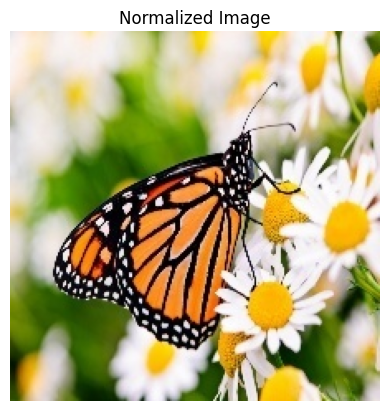

[[[0.8980392  0.8901961  0.9019608 ]
  [0.9098039  0.9019608  0.9137255 ]
  [0.93333334 0.9098039  0.91764706]
  ...
  [0.54509807 0.6039216  0.24705882]
  [0.4862745  0.5764706  0.15294118]
  [0.4117647  0.5176471  0.06666667]]

 [[0.9098039  0.9019608  0.9137255 ]
  [0.92156863 0.9137255  0.9254902 ]
  [0.94509804 0.92156863 0.92941177]
  ...
  [0.4745098  0.5411765  0.16470589]
  [0.43137255 0.52156866 0.09803922]
  [0.40784314 0.5137255  0.0627451 ]]

 [[0.91764706 0.9098039  0.92156863]
  [0.9254902  0.91764706 0.92941177]
  [0.9490196  0.9254902  0.93333334]
  ...
  [0.40784314 0.49019608 0.07843138]
  [0.39215687 0.49803922 0.05490196]
  [0.4        0.5137255  0.05098039]]

 ...

 [[0.18039216 0.28235295 0.        ]
  [0.17254902 0.28235295 0.        ]
  [0.17254902 0.2901961  0.        ]
  ...
  [0.8980392  0.8627451  0.88235295]
  [0.89411765 0.85490197 0.8862745 ]
  [0.89411765 0.85490197 0.8862745 ]]

 [[0.18039216 0.2901961  0.        ]
  [0.18039216 0.2901961  0.        ]


In [ ]:

def normalize_image(image):
    """
    This function takes in an image and returns the same image normalized on a 0 to 1 scale
    """
    if image is None:
        return None
    return ((image - np.min(image)) / (np.max(image) - np.min(image))).astype(np.float32)
# Load example image
image = cv2.imread("/content/drive/MyDrive/AjayButterflyProject/images/train/MONARCH/Image_4.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

normalized_image = normalize_image(image)

if normalized_image is not None:
    image_for_display = (normalized_image * 255).astype(np.uint8)#when trying to fix the code, chat GPT suggestedx doing this

    normalized_image.shape
    #plt.imshow(cv2.cvtColor(normalized_image, cv2.COLOR_BGR2RGB))

    plt.imshow(normalized_image)
    plt.axis('off')
    plt.title("Normalized Image")
    plt.show()
    normalized_image.shape
    print(normalized_image)
else:
    print("Could not normalize the image because it was not loaded correctly.")




In [ ]:
# Assume image is in RGB and scaled to [0, 1]
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

normalized_image = (normalized_image - mean) / std

In [ ]:
'''
#@title undersampling to remove some nonmonarchs as per chat gpt suggestion
import numpy as np


# Step 1: Find indices
monarch_indices = np.where(y_train == 1)[0]
non_monarch_indices = np.where(y_train == 0)[0]

# Step 2: Undersample non-monarchs to match monarchs
n_monarchs = len(monarch_indices)
np.random.seed(42)
desired_non_monarchs = 802  # ← your custom number here
undersampled_non_monarch_indices = np.random.choice(non_monarch_indices, size=desired_non_monarchs, replace=False)

# Step 3: Combine the balanced indices
balanced_indices = np.concatenate([monarch_indices, undersampled_non_monarch_indices])
np.random.shuffle(balanced_indices)

# Step 4: Subset the training data
X_train_balanced = X_train[balanced_indices]
y_train_balanced = y_train[balanced_indices]

X_train = X_train_balanced
y_train = y_train_balanced
'''

In [ ]:
# --- Split + undersample training set ---
import numpy as np
from sklearn.model_selection import train_test_split

# 1) Make sure arrays are numpy
X = images.astype(np.float32)
y = labels.astype(np.int64)

# Optional: sanity check class counts
unique, counts = np.unique(y, return_counts=True)
print("Full set class counts {label: count}:", dict(zip(unique, counts)))

# 2) Stratified split (keeps class proportions in train/test)
#    If you have very few monarchs, keep test_size modest (e.g., 0.2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Before balancing -> train counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Before balancing -> test  counts:", dict(zip(*np.unique(y_test,  return_counts=True))))

# 3) Undersample ONLY the training set (keep test set untouched for fair eval)
np.random.seed(42)
mon_idx  = np.where(y_train == 1)[0]
non_idx  = np.where(y_train == 0)[0]

# Choose how many non-monarchs to keep (<= available)
desired_non_monarchs = 802  # <- adjust as you like
desired_non_monarchs = min(desired_non_monarchs, len(non_idx))

sel_non_idx = np.random.choice(non_idx, size=desired_non_monarchs, replace=False)
balanced_idx = np.concatenate([mon_idx, sel_non_idx])
np.random.shuffle(balanced_idx)

X_train_balanced = X_train[balanced_idx]
y_train_balanced = y_train[balanced_idx]

print("After balancing -> train counts:", dict(zip(*np.unique(y_train_balanced, return_counts=True))))
print("Test set (unchanged) counts     :", dict(zip(*np.unique(y_test, return_counts=True))))

# 4) Train on X_train_balanced/y_train_balanced; evaluate on X_test/y_test
# model.fit(X_train_balanced, y_train_balanced)
# model.score(X_test, y_test)


Full set class counts {label: count}: {np.int64(0): np.int64(6409), np.int64(1): np.int64(892)}
Before balancing -> train counts: {np.int64(0): np.int64(5126), np.int64(1): np.int64(714)}
Before balancing -> test  counts: {np.int64(0): np.int64(1283), np.int64(1): np.int64(178)}
After balancing -> train counts: {np.int64(0): np.int64(802), np.int64(1): np.int64(714)}
Test set (unchanged) counts     : {np.int64(0): np.int64(1283), np.int64(1): np.int64(178)}


In [ ]:
#@title model creation

X = normalize_image(images)
y = df['label_bin'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(np.shape(X))
print(np.shape(X_train))
print(np.shape(X_test))
print(np.shape(y_train))


(7301, 224, 224, 3)
(5840, 224, 224, 3)
(1461, 224, 224, 3)
(5840,)


In [ ]:
print(type(images), len(images))
print(images[:])  # Peek at the first few entries

<class 'numpy.ndarray'> 7301
[[[[0.63921569 0.78039216 0.60784314]
   [0.65098039 0.79215686 0.61960784]
   [0.6745098  0.79607843 0.63137255]
   ...
   [0.75686275 0.63921569 0.59607843]
   [0.76862745 0.65098039 0.61176471]
   [0.77254902 0.65882353 0.62745098]]

  [[0.63529412 0.77647059 0.60392157]
   [0.64705882 0.78823529 0.61568627]
   [0.66666667 0.79607843 0.62745098]
   ...
   [0.76078431 0.64705882 0.59215686]
   [0.76470588 0.65490196 0.61176471]
   [0.76862745 0.6627451  0.61960784]]

  [[0.63137255 0.77647059 0.60392157]
   [0.64705882 0.78823529 0.61568627]
   [0.67058824 0.79607843 0.63529412]
   ...
   [0.75686275 0.65098039 0.58431373]
   [0.76078431 0.65882353 0.60784314]
   [0.76470588 0.6745098  0.61960784]]

  ...

  [[0.41568627 0.43921569 0.10196078]
   [0.32941176 0.37254902 0.0627451 ]
   [0.28235294 0.36470588 0.10196078]
   ...
   [0.70196078 0.47058824 0.00784314]
   [0.73333333 0.50196078 0.04705882]
   [0.75294118 0.51764706 0.07058824]]

  [[0.5372549  0

In [ ]:
from sklearn.model_selection import train_test_split
#@title train test split according to chatgpt to keep it below 2400
# Step 1: Normalize

#X = normalize_image(images)
#y = df['label_bin'].values  # ensure this is a numpy array
'''
# Step 2: Random train/test split
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
'''

# Step 2: Random train/test split
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X_train_balanced, y_train_balanced, test_size=0.2, stratify=y_train_balanced, random_state=42
)

# Step 3: Get monarch indices (safe!)
monarchIndices = np.where(y_train == 1)#[0]

# Now this is safe:
X_monarch = X_train[monarchIndices]

In [ ]:
#@title undersampling to remove some nonmonarchs as per chat gpt suggestion
import numpy as np


# Step 1: Find indices
monarch_indices = np.where(y_train == 1)[0]
non_monarch_indices = np.where(y_train == 0)[0]

# Step 2: Undersample non-monarchs to match monarchs
n_monarchs = len(monarch_indices)
np.random.seed(42)
desired_non_monarchs = 571  # ← your custom number here
undersampled_non_monarch_indices = np.random.choice(non_monarch_indices, size=desired_non_monarchs, replace=False)

# Step 3: Combine the balanced indices
balanced_indices = np.concatenate([monarch_indices, undersampled_non_monarch_indices])
np.random.shuffle(balanced_indices)

# Step 4: Subset the training data
X_train_balanced = X_train[balanced_indices]
y_train_balanced = y_train[balanced_indices]

X_train = X_train_balanced
y_train = y_train_balanced


In [ ]:
print("Class counts:", dict(zip(*np.unique(y_train, return_counts=True))))


Class counts: {np.int64(0): np.int64(571), np.int64(1): np.int64(571)}


In [ ]:
#print(np.shape(X_test))
#print(np.shape(y_test))
print(np.shape(X_train))
print(np.shape(y_train))
#print(y_test.value_counts())
'''
monarchNum = 0
for i in range(len(y_train)):
  if y_train[i] == 1:
    monarchNum = monarchNum + 1
print(monarchNum)
'''
#print(pd.Series(y_test).value_counts())   # For test set
#print(pd.Series(y_train).value_counts())  # For train set

(1142, 224, 224, 3)
(1142,)


'\nmonarchNum = 0\nfor i in range(len(y_train)):\n  if y_train[i] == 1:\n    monarchNum = monarchNum + 1\nprint(monarchNum)\n'

In [ ]:

'''#@title undersampling to remove some nonmonarchs as per chat gpt suggestion
import numpy as np

# Step 1: Find indices
monarch_indices = np.where(y_train == 1)[0]
non_monarch_indices = np.where(y_train == 0)[0]

# Step 2: Undersample non-monarchs to match monarchs
n_monarchs = len(monarch_indices)
np.random.seed(42)
desired_non_monarchs = 802  # ← your custom number here
undersampled_non_monarch_indices = np.random.choice(non_monarch_indices, size=desired_non_monarchs, replace=False)

# Step 3: Combine the balanced indices
balanced_indices = np.concatenate([monarch_indices, undersampled_non_monarch_indices])
np.random.shuffle(balanced_indices)

# Step 4: Subset the training data
X_train_balanced = X_train[balanced_indices]
y_train_balanced = y_train[balanced_indices]

X_train = X_train_balanced
y_train = y_train_balanced
'''

In [ ]:
print(np.shape(X_test))
print(np.shape(y_test))
print(np.shape(X_train))
print(np.shape(y_train))
#print(y_test.value_counts())
'''
monarchNum = 0
for i in range(len(y_train)):
  if y_train[i] == 1:
    monarchNum = monarchNum + 1
print(monarchNum)
'''
print(pd.Series(y_test).value_counts())   # For test set
print(pd.Series(y_train).value_counts())  # For train set

(304, 224, 224, 3)
(304,)
(1142, 224, 224, 3)
(1142,)
0    161
1    143
Name: count, dtype: int64
1    571
0    571
Name: count, dtype: int64


In [ ]:
import os
'''
# List files in the directory
new_monarch_data = '/content/drive/MyDrive/archive/test_data_monarchs'
print(os.listdir(new_monarch_data))
'''

In [ ]:
'''
#@title Load new data from the directory(commented)
new_monarch_data_dir = '/content/drive/MyDrive/archive/test_data_monarchs'
new_image_files = sorted([os.path.join(new_monarch_data_dir, img) for img in os.listdir(new_monarch_data_dir) if img.endswith(".jpg")])

new_images = []
new_labels = []

for img_file in new_image_files:
    img = cv2.imread(img_file)
    if img is not None:
        img = cv2.resize(img, (224, 224))        # or 224x224
        img = img / 255.0                        # Normalize
        new_images.append(img)
        # Assuming all images in this directory are Monarchs (label 1)
        new_labels.append(1)

new_images = np.array(new_images)
new_labels = np.array(new_labels)

# Assuming new_labels is already defined and is a numpy array with the correct shape
X_train = np.concatenate((X_train, new_images), axis=0)
y_train = np.concatenate((y_train, new_labels), axis=0)

print("New images added to training data.")
print("Updated X_train shape:", X_train.shape)
print("Updated y_train shape:", y_train.shape)
'''

In [ ]:
print("X_train shape:", X_train.shape)
#print("new_images shape:", new_images.shape)
print("y_train shape:", y_train.shape)
#print("new_labels shape:", new_labels.shape)


X_train shape: (1142, 224, 224, 3)
y_train shape: (1142,)


In [ ]:
'''
#new code  for above error
import os
import cv2
import numpy as np

# Load new monarch images
new_monarch_data_dir = '/content/drive/MyDrive/archive/test_data_monarchs'
new_image_files = sorted([
    os.path.join(new_monarch_data_dir, img)
    for img in os.listdir(new_monarch_data_dir)
    if img.lower().endswith(".jpg")
])

new_images = []
new_labels = []

for img_file in new_image_files:
    img = cv2.imread(img_file)
    if img is not None:
        img = cv2.resize(img, (224, 224))
        img = img / 255.0
        new_images.append(img)
        new_labels.append(1)  # All are monarchs

# Convert to arrays
new_images = np.array(new_images)
new_labels = np.array(new_labels)

# ✅ Check and fix shapes
if X_train.ndim == 1:
    X_train = np.array(X_train)
if y_train.ndim == 1:
    y_train = np.array(y_train)

# ✅ Final concatenation
X_train = np.concatenate([X_train, new_images], axis=0)
y_train = np.concatenate([y_train, new_labels], axis=0)

print("✅ New images added to training data.")
print("🔷 Updated X_train shape:", X_train.shape)
print("🔷 Updated y_train shape:", y_train.shape)
'''

In [ ]:
print(np.shape(X_test))
print(np.shape(y_test))
print(np.shape(X_train))
print(np.shape(y_train))
#print(y_test.value_counts())
'''
monarchNum = 0
for i in range(len(y_train)):
  if y_train[i] == 1:
    monarchNum = monarchNum + 1
print(monarchNum)
'''
print(pd.Series(y_test).value_counts())   # For test set
print(pd.Series(y_train).value_counts())  # For train set

(304, 224, 224, 3)
(304,)
(1142, 224, 224, 3)
(1142,)
0    161
1    143
Name: count, dtype: int64
1    571
0    571
Name: count, dtype: int64


In [ ]:
# Load data from the directory

def load_images_in_batches(image_dir, label=1, batch_size=32, target_size=(224, 224)):
    import os
    import cv2
    import numpy as np

    image_paths = sorted([
        os.path.join(image_dir, fname)
        for fname in os.listdir(image_dir)
        if fname.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i + batch_size]
        images = []
        labels = []

        for path in batch_paths:
            img = cv2.imread(path)
            if img is not None:
                img = cv2.resize(img, target_size)
                img = img / 255.0  # ✅ THIS IS THE NORMALIZATION
                images.append(img)
                labels.append(label)

        yield np.array(images), np.array(labels)


In [ ]:
'''
monarch_dir = '/content/drive/MyDrive/archive/new_monarch_butterfly_data_265pxl/data/train/monarch'
batch_generator = load_images_in_batches(monarch_dir, label=1, batch_size=32)

# Initialize X_train and y_train as empty lists
X_train_list = []
y_train_list = []

for X_batch, y_batch in batch_generator:
    print("X_batch shape:", X_batch.shape)
    print("y_batch shape:", y_batch.shape)

    # Append the batches directly to the lists
    X_train_list.append(X_batch)
    y_train_list.append(y_batch)

# Concatenate all batches into single NumPy arrays
X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)

print("✅ Final dataset shapes:", X_train.shape, y_train.shape)
'''

In [ ]:
'''
import os
import cv2

save_dir = '/content/monarch_500_export'
os.makedirs(save_dir, exist_ok=True)

# Save each image
for i, img_array in enumerate(X_monarch_500):
    img_bgr = (img_array * 255).astype('uint8')  # convert back to 0-255 scale
    save_path = os.path.join(save_dir, f"monarch_{i+1:03d}.jpg")
    cv2.imwrite(save_path, img_bgr)

print(f"✅ Saved {len(X_monarch_500)} images to '{save_dir}'")
'''

In [ ]:
'''
print(np.shape(new_images))
print(np.shape(new_labels))
'''

In [ ]:
''''
# Assuming new_labels is already defined and is a numpy array with the correct shape
X_train = np.concatenate((X_train, new_images), axis=0)
y_train = np.concatenate((y_train, new_labels), axis=0)

print("New images added to training data.")
print("Updated X_train shape:", X_train.shape)
print("Updated y_train shape:", y_train.shape)
'''

In [ ]:
#np.shape(new_labels)

In [ ]:
print(np.shape(X_test))
print(np.shape(y_test))
print(np.shape(X_train))
print(np.shape(y_train))
#print(y_test.value_counts())
'''
monarchNum = 0
for i in range(len(y_train)):
  if y_train[i] == 1:
    monarchNum = monarchNum + 1
print(monarchNum)
'''
print(pd.Series(y_test).value_counts())   # For test set
print(pd.Series(y_train).value_counts())  # For train set



(304, 224, 224, 3)
(304,)
(1142, 224, 224, 3)
(1142,)
0    161
1    143
Name: count, dtype: int64
1    571
0    571
Name: count, dtype: int64


In [ ]:
unique, counts = np.unique(y_train_balanced, return_counts=True)
print("Balanced training class distribution:", dict(zip(unique, counts)))

Balanced training class distribution: {np.int64(0): np.int64(571), np.int64(1): np.int64(571)}


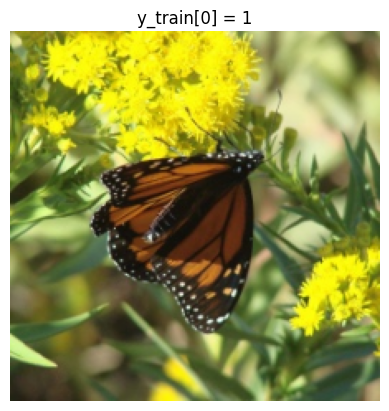

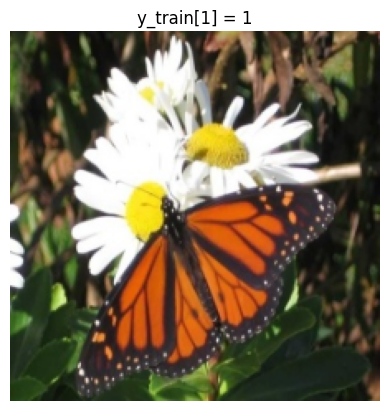

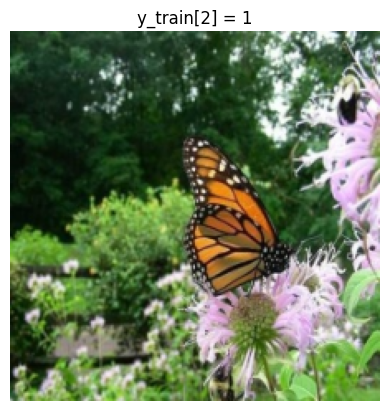

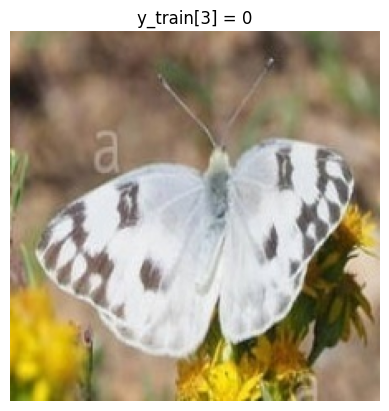

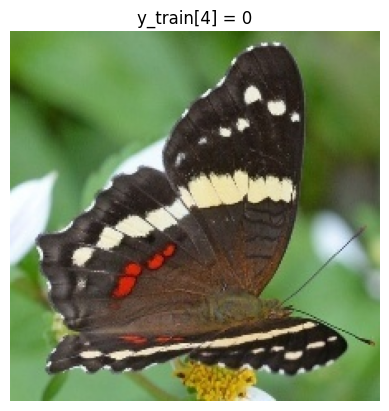

In [ ]:
for i in range(5):
    plt.imshow(X_train[i])
    plt.title(f"y_train[{i}] = {y_train[i]}")
    plt.axis('off')
    plt.show()

In [ ]:
# Convert X_train and X_test to NumPy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)

# Now you can reshape
X_train_flattened = X_train.reshape(X_train.shape[0], -1)
X_test_flattened = X_test.reshape(X_test.shape[0], -1)
print("X_train_flattened dimension: ", X_train_flattened.shape)
print("X_test_flattened dimension: ", X_test_flattened.shape)

X_train_flattened dimension:  (1142, 150528)
X_test_flattened dimension:  (304, 150528)


In [ ]:
'''
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors = 3) # try playing around with different values of n_neighbors

knn_model.fit(X_train_flattened, y_train)

predictions = knn_model.predict(X_test_flattened)

from sklearn.metrics import accuracy_score

accuracy_score(y_test, predictions)
'''

In [ ]:
'''
# STEP 1: Initialization
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(max_depth=2, random_state=0)
# STEP 2: Training
random_forest_model.fit(X_train_flattened, y_train)
# STEP 3: Prediction
predictions = random_forest_model.predict(X_test_flattened)
# STEP 4: Evaluation
from sklearn.metrics import accuracy_score

accuracy_score(y_test, predictions)
'''

In [ ]:
'''
print(np.shape(X_test))
print(np.shape(y_test))
print(np.shape(X_train))
print(np.shape(y_train))
#print(y_test.value_counts())

print(pd.Series(y_test).value_counts())   # For test set
print(pd.Series(y_train).value_counts())  # For train set

'''

In [ ]:
#@title Use NumPy's np.unique with return_counts=True   suggested by chatgpt
import numpy as np

unique, counts = np.unique(y_test, return_counts=True)
print("Label distribution in y_test:")
print(dict(zip(unique, counts)))

Label distribution in y_test:
{np.int64(0): np.int64(161), np.int64(1): np.int64(143)}


In [ ]:
'''
print(type(y_train))
y_train = y_train.values
'''

In [ ]:
print(y_train)

[1 1 1 ... 1 0 0]


In [ ]:
y_train_series = pd.Series(y_train)
print(y_train_series.value_counts())

1    571
0    571
Name: count, dtype: int64


In [ ]:
'''
monarchIndices = df.index[df['label'] == 'MONARCH'].tolist()
print(monarchIndices)
plt.imshow(images[monarchIndices[1]])
print(images[monarchIndices[1]].shape)
'''

In [ ]:
'''
monarchIndices = np.where(y_train == 1)[0].tolist()
print(monarchIndices)
plt.imshow(images[monarchIndices[1]])
print(images[monarchIndices[1]].shape)

# Check shape and content match
print(len(images), len(y_train))  # Should be equal

# Check if any monarchIndices exist
print("Number of monarchs:", sum(y_train == 1))

# Show a few images marked as monarch
for i in monarchIndices[:5]:
    plt.imshow(images[i])
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
    plt.show()
'''

In [ ]:
print(np.shape(X_test))
print(np.shape(y_test))
print(np.shape(X_train))
print(np.shape(y_train))
#print(y_test.value_counts())
'''
monarchNum = 0
for i in range(len(y_train)):
  if y_train[i] == 1:
    monarchNum = monarchNum + 1
print(monarchNum)
'''
print(pd.Series(y_test).value_counts())   # For test set
print(pd.Series(y_train).value_counts())  # For train set

(304, 224, 224, 3)
(304,)
(1142, 224, 224, 3)
(1142,)
0    161
1    143
Name: count, dtype: int64
1    571
0    571
Name: count, dtype: int64


First few y_train values: [1 1 1 0 0 0 0 0 0 0]
First few image shapes: [(224, 224, 3), (224, 224, 3), (224, 224, 3), (224, 224, 3), (224, 224, 3), (224, 224, 3), (224, 224, 3), (224, 224, 3), (224, 224, 3), (224, 224, 3)]


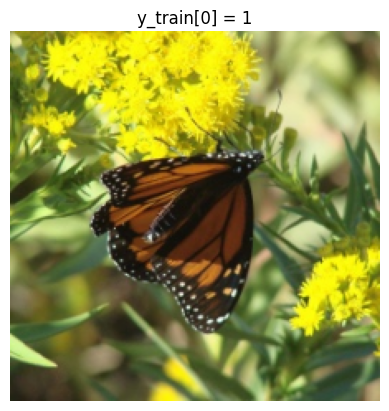

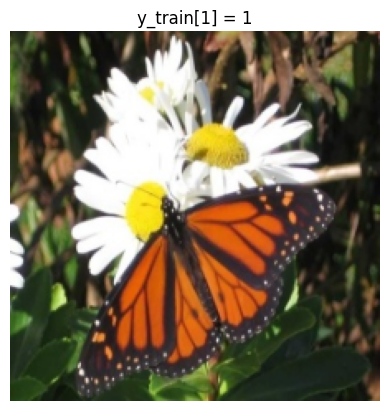

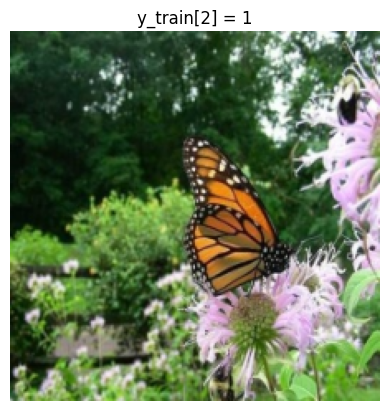

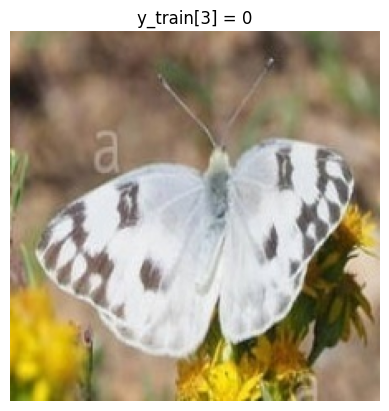

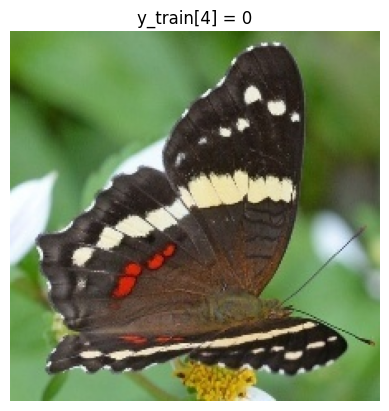

In [ ]:
print("First few y_train values:", y_train[:10])
print("First few image shapes:", [img.shape for img in X_train[:10]])
for i in range(5):
    plt.imshow(X_train[i])
    plt.title(f"y_train[{i}] = {y_train[i]}")
    plt.axis('off')
    plt.show()


In [ ]:
'''
monarchIndices = np.where(y_test == 1)[0].tolist()
print(monarchIndices)
'''

In [ ]:
'''
#@title data augmentation rotate
# assume
#   X_train: shape (n_samples, n_features)
#   y_train: shape (n_samples,)

# boolean mask of where y_train == 1
mask = (y_train == 1)

# apply it to X_train
X_train_filtered = X_train[mask]

# apply it to X_train
y_train_filtered = y_train[mask]

print(X_train_filtered.shape)
for i in range(len(X_train_filtered)):
  rotate(X_train_filtered[i], 30)



X_train = np.concatenate((X_train, X_train_filtered), axis=0)
y_train = np.concatenate((y_train, y_train_filtered), axis=0)
X_train_filtered = (X_train_filtered - np.min(X_train_filtered)) / (np.max(X_train_filtered) - np.min(X_train_filtered))
print()
'''

In [ ]:
'''
X_monarch = X_train[monarchIndices]
#y_monarch = y_train[monarchIndices]  # if y_train aligns with df

augmented_images = []
augmented_labels = []
augmented_labels.append('MONARCH')
#augmented_labels.append(1)

print(X_train.shape)
print(np.array(augmented_images).shape)

for img in X_monarch:
    rotated_img = rotate(img, 30)  # Or use your custom rotate function
    augmented_images.append(rotated_img)
    augmented_labels.append(1)  # Or 'MONARCH' depending on your label type

#X_train = np.concatenate((X_train, np.array(augmented_images)), axis=0)

y_train = np.concatenate((y_train, np.array(augmented_labels)), axis=0)
'''


In [ ]:
'''
# Step 1: Extract MONARCH images
# Recalculate monarch_indices based on the current y_train
monarch_indices = np.where(y_train == 1)[0]
X_monarch = X_train[monarch_indices]

# Step 2: Prepare for augmentation
augmented_images = []
augmented_labels = []
print(np.shape(augmented_images))

# Step 3: Rotate and store
for img in X_monarch:
    rotated_img = rotate(img, 20)  # Your rotate function must return same shape
    augmented_images.append(rotated_img)
    augmented_labels.append(1)  # or 1 depending on your label type

# Step 4: Convert to numpy and concatenate
augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

print("Original X_train shape:", X_train.shape)
print("Augmented images shape:", augmented_images.shape)

X_train = np.concatenate((X_train, augmented_images), axis=0)
y_train = np.concatenate((y_train, augmented_labels), axis=0)
# Remove concatenation to X_test and y_test
# X_test = np.concatenate((X_test, augmented_images), axis=0)
# y_test = np.concatenate((y_test, augmented_labels), axis=0)
'''

In [ ]:
'''
# Step 1: Extract MONARCH images
X_monarch = X_train[monarchIndices]

# Step 2: Prepare for augmentation
augmented_images = []
augmented_labels = []
print(np.shape(augmented_images))

# Step 3: Rotate and store
for img in X_monarch:
    rotated_img = rotate(img, 20)  # Your rotate function must return same shape
    augmented_images.append(rotated_img)
    augmented_labels.append(True)  # or 1 depending on your label type

# Step 4: Convert to numpy and concatenate
augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

print("Original X_train shape:", X_train.shape)
print("Augmented images shape:", augmented_images.shape)

X_train = np.concatenate((X_train, augmented_images), axis=0)
y_train = np.concatenate((y_train, augmented_labels), axis=0)
X_test = np.concatenate((X_test, augmented_images), axis=0)
y_test = np.concatenate((y_test, augmented_labels), axis=0)
'''

In [ ]:
'''
#@title data augmentation scale
# boolean mask of where y_train == 1
mask = (y_train == 1)

# apply it to X_train
X_train_filtered = X_train[mask]

# apply it to X_train
y_train_filtered = y_train[mask]

print(X_train_filtered.shape)
for i in range(len(X_train_filtered)):
  scale(X_train_filtered[i], 1.5)


X_train = np.concatenate((X_train, X_train_filtered), axis=0)
y_train = np.concatenate((y_train, y_train_filtered), axis=0)
X_train_filtered = (X_train_filtered - np.min(X_train_filtered)) / (np.max(X_train_filtered) - np.min(X_train_filtered))
print()
'''

In [ ]:
'''
for i in range(10):
  # Step 1: Extract MONARCH images
  X_monarch = X_train[monarch_indices]

  # Step 2: Prepare for augmentation
  augmented_images = []
  augmented_labels = []
  print(np.shape(augmented_images))


  # Step 3: scale and store
  for img in X_monarch:
      scale_img = scale(img, i)  # Your rotate function must return same shape
      augmented_images.append(scale_img)
      augmented_labels.append(1)  # or 1 depending on your label type
      #print(np.shape(augmented_images))

  # Step 4: Convert to numpy and concatenate
  augmented_images = np.array(augmented_images)
  augmented_labels = np.array(augmented_labels)



  X_train = np.concatenate((X_train, augmented_images), axis=0)
  y_train = np.concatenate((y_train, augmented_labels), axis=0)
  plt.imshow(augmented_images[i])

print("Original X_train shape:", X_train.shape)
print("Augmented images shape:", augmented_images.shape)
'''

In [ ]:
'''
# Step 1: Extract MONARCH images
X_monarch = X_train[monarchIndices]

# Step 2: Prepare for augmentation
augmented_images = []
augmented_labels = []
print(np.shape(augmented_images))


# Step 3: scale and store
for img in X_monarch:
    scale_img = scale(img, 1)  # Your rotate function must return same shape
    augmented_images.append(scale_img)
    augmented_labels.append(True)  # or 1 depending on your label type


# Step 4: Convert to numpy and concatenate
augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

print("Original X_train shape:", X_train.shape)
print("Augmented images shape:", augmented_images.shape)

X_train = np.concatenate((X_train, augmented_images), axis=0)
y_train = np.concatenate((y_train, augmented_labels), axis=0)
X_test = np.concatenate((X_test, augmented_images), axis=0)
y_test = np.concatenate((y_test, augmented_labels), axis=0)
'''

In [ ]:
'''
#@title data augmentation shear
# boolean mask of where y_train == 1
mask = (y_train == 1)

# apply it to X_train
X_train_filtered = X_train[mask]

# apply it to X_train
y_train_filtered = y_train[mask]

print(X_train_filtered.shape)
for i in range(len(X_train_filtered)):
  shear(X_train_filtered[i], 20)


X_train = np.concatenate((X_train, X_train_filtered), axis=0)
y_train = np.concatenate((y_train, y_train_filtered), axis=0)
X_train_filtered = (X_train_filtered - np.min(X_train_filtered)) / (np.max(X_train_filtered) - np.min(X_train_filtered))
'''

In [ ]:
'''
for i in range(10):
  # Step 1: Extract MONARCH images
  X_monarch = X_train[monarch_indices]

  # Step 2: Prepare for augmentation
  augmented_images = []
  augmented_labels = []
  print(np.shape(augmented_images))


  # Step 3: shear and store
  for img in X_monarch:
      shear_img = shear(img, i)  # Your rotate function must return same shape
      augmented_images.append(shear_img)
      augmented_labels.append(1)  # or 1 depending on your label type
     # print(np.shape(augmented_images))

  # Step 4: Convert to numpy and concatenate
  augmented_images = np.array(augmented_images)
  augmented_labels = np.array(augmented_labels)

  print("Original X_train shape:", X_train.shape)
  print("Augmented images shape:", augmented_images.shape)
  plt.imshow(augmented_images[i])

  X_train = np.concatenate((X_train, augmented_images), axis=0)
  y_train = np.concatenate((y_train, augmented_labels), axis=0)

'''

In [ ]:
from collections import Counter
Counter(y_train)

Counter({np.int64(1): 571, np.int64(0): 571})

In [ ]:
'''
# Step 1: Extract MONARCH images
X_monarch = X_train[monarchIndices]

# Step 2: Prepare for augmentation
augmented_images = []
augmented_labels = []
print(np.shape(augmented_images))


# Step 3: shear and store
for img in X_monarch:
    shear_img = shear(img, 1)  # Your rotate function must return same shape
    augmented_images.append(scale_img)
    augmented_labels.append(True)  # or 1 depending on your label type


# Step 4: Convert to numpy and concatenate
augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

print("Original X_train shape:", X_train.shape)
print("Augmented images shape:", augmented_images.shape)

X_train = np.concatenate((X_train, augmented_images), axis=0)
y_train = np.concatenate((y_train, augmented_labels), axis=0)
X_test = np.concatenate((X_test, augmented_images), axis=0)
y_test = np.concatenate((y_test, augmented_labels), axis=0)
'''

In [ ]:
'''
#@title data augmentation flip
# boolean mask of where y_train == 1
mask = (y_train == 1)

# apply it to X_train
X_train_filtered = X_train[mask]

# apply it to X_train
y_train_filtered = y_train[mask]

print(X_train_filtered.shape)
for i in range(len(X_train_filtered)):
  flip_left_right(X_train_filtered[i], prob = 0.5)


X_train = np.concatenate((X_train, X_train_filtered), axis=0)
y_train = np.concatenate((y_train, y_train_filtered), axis=0)
X_train_filtered = (X_train_filtered - np.min(X_train_filtered)) / (np.max(X_train_filtered) - np.min(X_train_filtered))
'''

In [ ]:
'''
#for i in range(10):
# Step 1: Extract MONARCH images
X_monarch = X_train[monarch_indices]

# Step 2: Prepare for augmentation
augmented_images = []
augmented_labels = []
print(np.shape(augmented_images))


# Step 3: flip and store
for img in X_monarch:
    flip_LR_img = flip_left_right(img, prob = 1)  # Your rotate function must return same shape
    augmented_images.append(flip_LR_img)
    augmented_labels.append(1)  # or 1 depending on your label type
    print(np.shape(augmented_images))

# Step 4: Convert to numpy and concatenate
augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

print("Original X_train shape:", X_train.shape)
print("Augmented images shape:", augmented_images.shape)

X_train = np.concatenate((X_train, augmented_images), axis=0)
y_train = np.concatenate((y_train, augmented_labels), axis=0)

'''

In [ ]:
'''
# Step 1: Extract MONARCH images
X_monarch = X_train[monarchIndices]

# Step 2: Prepare for augmentation
augmented_images = []
augmented_labels = []
print(np.shape(augmented_images))


# Step 3: flip and store
for img in X_monarch:
    flip_LR_img = flip_left_right(img, prob = 1)  # Your rotate function must return same shape
    augmented_images.append(flip_LR_img)


# Step 4: Convert to numpy and concatenate
augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

print("Original X_train shape:", X_train.shape)
print("Augmented images shape:", augmented_images.shape)

X_train = np.concatenate((X_train, augmented_images), axis=0)
y_train = np.concatenate((y_train, augmented_labels), axis=0)
X_test = np.concatenate((X_test, augmented_images), axis=0)
y_test = np.concatenate((y_test, augmented_labels), axis=0)
'''

In [ ]:
'''
#for i in range(20):
#@title data augmentation flip up/down
# Step 1: Extract MONARCH images
X_monarch = X_train[monarch_indices]

# Step 2: Prepare for augmentation
augmented_images = []
augmented_labels = []
print(np.shape(augmented_images))


# Step 3: flip and store
for img in X_monarch:
    flip_UD_img = flip_up_down(img, prob = 1)  # Your rotate function must return same shape
    augmented_images.append(flip_UD_img)
    augmented_labels.append(1)  # or 1 depending on your label type
#    print(np.shape(augmented_images))

# Step 4: Convert to numpy and concatenate
augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

print("Original X_train shape:", X_train.shape)
print("Augmented images shape:", augmented_images.shape)

X_train = np.concatenate((X_train, augmented_images), axis=0)
y_train = np.concatenate((y_train, augmented_labels), axis=0)
'''


In [ ]:
'''
#@title data augmentation flip up/down
# Step 1: Extract MONARCH images
X_monarch = X_train[monarchIndices]

# Step 2: Prepare for augmentation
augmented_images = []
augmented_labels = []
print(np.shape(augmented_images))


# Step 3: flip and store
for img in X_monarch:
    flip_UD_img = flip_up_down(img, prob = 1)  # Your rotate function must return same shape
    augmented_images.append(flip_UD_img)
    augmented_labels.append(True)  # or 1 depending on your label type

# Step 4: Convert to numpy and concatenate
augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

print("Original X_train shape:", X_train.shape)
print("Augmented images shape:", augmented_images.shape)

X_train = np.concatenate((X_train, augmented_images), axis=0)
y_train = np.concatenate((y_train, augmented_labels), axis=0)
X_test = np.concatenate((X_test, augmented_images), axis=0)
y_test = np.concatenate((y_test, augmented_labels), axis=0)
'''

In [ ]:
'''
#@title data augmentation remove color
# Step 1: Extract MONARCH images
X_monarch = X_train[monarch_indices]

# Step 2: Prepare for augmentation
augmented_images = []
augmented_labels = []
print(np.shape(augmented_images))


# Step 3: flip and store
for img in X_monarch:
    color_removed_img = remove_color(img, channel=0)
    augmented_images.append(color_removed_img)
    augmented_labels.append(1)  # or 1 depending on your label type
  #  print(np.shape(augmented_images))

# Step 4: Convert to numpy and concatenate
augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

print("Original X_train shape:", X_train.shape)
print("Augmented images shape:", augmented_images.shape)

X_train = np.concatenate((X_train, augmented_images), axis=0)
y_train = np.concatenate((y_train, augmented_labels), axis=0)
'''


In [ ]:
'''
#@title data augmentation remove color
# Step 1: Extract MONARCH images
X_monarch = X_train[monarch_indices]

# Step 2: Prepare for augmentation
augmented_images = []
augmented_labels = []
print(np.shape(augmented_images))


# Step 3: flip and store
for img in X_monarch:
    removeColor = remove_color(img, channel = 1)  # Your rotate function must return same shape
    augmented_images.append(removeColor)
    augmented_labels.append(1)  # or 1 depending on your label type
 #   print(np.shape(augmented_images))

# Step 4: Convert to numpy and concatenate
augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

print("Original X_train shape:", X_train.shape)
print("Augmented images shape:", augmented_images.shape)

X_train = np.concatenate((X_train, augmented_images), axis=0)
y_train = np.concatenate((y_train, augmented_labels), axis=0)
'''


In [ ]:
'''
y_train_series = pd.Series(y_train)
print(y_train_series.value_counts())

y_test_series = pd.Series(y_test)
print(y_test_series.value_counts())

# Recalculate monarch_indices based on the current y_train
monarch_indices = np.where(y_train == 1)[0]

# Now X_monarch can be safely created using the updated indices
X_monarch = X_train[monarch_indices]

for img in X_monarch[:min(5, len(X_monarch))]: # Display up to 5 monarch images
  plt.imshow(img)
  plt.show()
  '''

In [ ]:

print(np.shape(X_test))
print(np.shape(y_test))
print(np.shape(X_train))
print(np.shape(y_train))
#print(y_test.value_counts())
'''
monarchNum = 0
for i in range(len(y_train)):
  if y_train[i] == 1:
    monarchNum = monarchNum + 1
print(monarchNum)
'''
print(pd.Series(y_test).value_counts())   # For test set
print(pd.Series(y_train).value_counts())  # For train set

(304, 224, 224, 3)
(304,)
(1142, 224, 224, 3)
(1142,)
0    161
1    143
Name: count, dtype: int64
1    571
0    571
Name: count, dtype: int64


In [ ]:
print("training")
print(y_train)
print("testing")

'''
for i in monarchIndices:
  print(y_test[i])
  '''

training
[1 1 1 ... 1 0 0]
testing


'\nfor i in monarchIndices:\n  print(y_test[i])\n  '

In [ ]:

class F1Score(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(y_pred > 0.5, tf.float32)
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + tf.keras.backend.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()


In [ ]:
'''
import os

train_path = '/content/drive/MyDrive/archive/train'
test_path = '/content/drive/MyDrive/archive/test'

for split in [train_path, test_path]:
    print(f"\nChecking: {split}")
    if not os.path.exists(split):
        print("❌ Directory does not exist.")
    else:
        for cls in os.listdir(split):
            class_path = os.path.join(split, cls)
            if os.path.isdir(class_path):
                images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                print(f"🟢 Class '{cls}': {len(images)} images")
            else:
                print(f"⚠️ '{cls}' is not a folder")
                '''

In [ ]:
'''
#@title had to organize data into monarch vs nonmonarch
import os

base = '/content/drive/MyDrive/archive/train'
classes = ['monarch', 'non_monarch']

for cls in classes:
    os.makedirs(os.path.join(base, cls), exist_ok=True)
'''

In [ ]:
import os

base = "/content/drive/MyDrive/AjayButterflyProject/images/train"

for fname in os.listdir(base):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        src = os.path.join(base, fname)
        dest_cls = 'monarch' if 'monarch' in fname.lower() else 'non_monarch'
        dest_dir = os.path.join(base, dest_cls)
        os.makedirs(dest_dir, exist_ok=True)  # ensure subfolder exists
        dest = os.path.join(dest_dir, fname)
        os.replace(src, dest)

In [ ]:
'''
for fname in os.listdir(base):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        src = os.path.join(base, fname)
        dest_cls = 'monarch' if 'monarch' in fname.lower() else 'non_monarch'
        dest = os.path.join(base, dest_cls, fname)
        os.replace(src, dest)
'''

In [ ]:
'''
import pandas as pd
import os

df = pd.read_csv('/content/drive/MyDrive/archive/Training_set.csv')
base = '/content/drive/MyDrive/archive/train' # Base directory where images are currently located

for _, row in df.iterrows():
    fname, label = row['filename'], row['label']
    # Determine the current subdirectory based on previous organization
    current_subdir = 'monarch' if 'monarch' in fname.lower() else 'non_monarch'
    src = os.path.join(base, current_subdir, fname)
    dest_dir = os.path.join(base, label)
    dest = os.path.join(dest_dir, fname)

    # Create the destination directory if it doesn't exist
    os.makedirs(dest_dir, exist_ok=True)

    # Check if the source file exists before attempting to move
    if os.path.exists(src):
        os.replace(src, dest)
    else:
        print(f"Warning: Source file not found: {src}")
'''

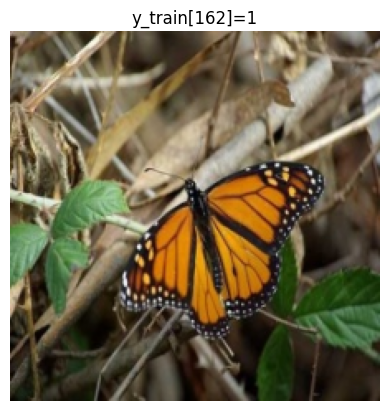

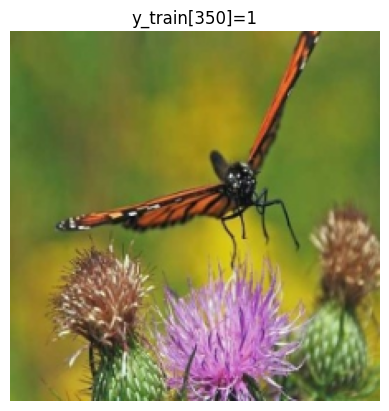

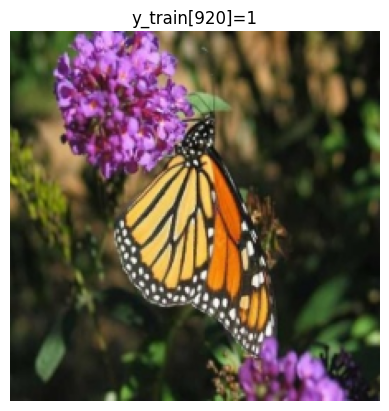

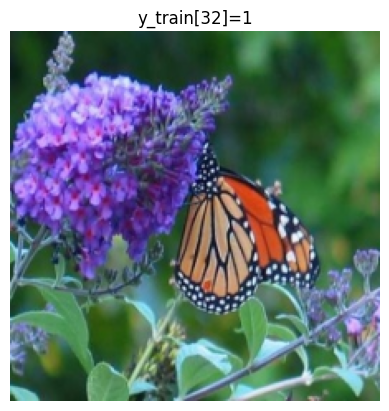

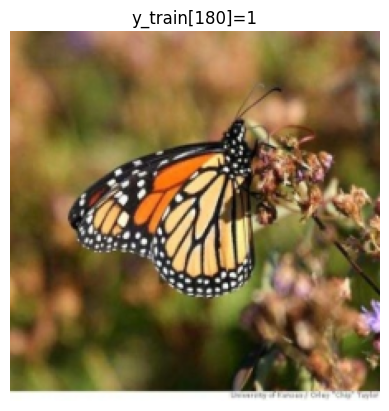

In [ ]:
import numpy as np
from collections import Counter

assert len(X_train) == len(y_train)
assert set(np.unique(y_train)).issubset({0,1})

# spot-check a few
idx = np.random.choice(np.where(y_train==1)[0], 5, replace=False)
for i in idx:
    plt.imshow(X_train[i]); plt.title(f"y_train[{i}]={y_train[i]}"); plt.axis('off'); plt.show()

In [ ]:
print(y_train[:100])

[1 1 1 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 1 1 1 0 1 0 1 1 0 1 1 0 0 1 1 1 0 0 1
 1 1 0 0 0 0 0 0 0 1 1 0 1 0 1 0 0 1 0 1 0 1 0 0 0 0 1 1 1 0 0 1 1 1 0 1 1
 1 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 0 1 0 1 1 1 0 0 0 1]


In [ ]:
def create_weighted_binary_crossentropy(zero_weight, one_weight):

    def weighted_binary_crossentropy(y_true, y_pred):

        # Original binary crossentropy (see losses.py):
        # K.mean(K.binary_crossentropy(y_true, y_pred), axis=-1)

        # Calculate the binary crossentropy
        b_ce = K.binary_crossentropy(y_true, y_pred)

        # Apply the weights
        weight_vector = y_true * one_weight + (1. - y_true) * zero_weight
        weighted_b_ce = weight_vector * b_ce

        # Return the mean error
        return K.mean(weighted_b_ce)

    return weighted_binary_crossentropy

In [ ]:
model = Sequential()
model.add(Reshape((224, 224, 3)))


'''
model.add(Conv2D(32, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
'''
###
###
### TODO: ADD MORE LAYERS HERE!!!!!
model.add(Conv2D(32, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
###
model.add(Conv2D(64, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
###
'''
model.add(Conv2D(128, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
'''
model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dense(1))
model.add(Activation('sigmoid'))


# Get model predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Compute F1 Score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")


# initiate RMSprop optimizer
opt = keras.optimizers.RMSprop(learning_rate=0.0001)

# Let's train the model using RMSprop
model.compile(
    loss='binary_crossentropy',
    optimizer=opt,
    metrics=['accuracy', Precision(), Recall(),F1Score()]
)
# Train the CNN and plot accuracy.
history = model.fit(X_train, y_train,

                    validation_data=(X_test, y_test),
                    epochs=20,batch_size=64)
#plot_acc(history)
model.save("monarch_classifier.keras")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 194ms/step
F1 Score: 0.4965
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.5359 - f1_score: 0.5486 - loss: 0.9576 - precision: 0.5340 - recall: 0.5639 - val_accuracy: 0.5395 - val_f1_score: 0.0541 - val_loss: 0.6749 - val_precision: 0.8000 - val_recall: 0.0280
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.6322 - f1_score: 0.6243 - loss: 0.6533 - precision: 0.6380 - recall: 0.6112 - val_accuracy: 0.6053 - val_f1_score: 0.7015 - val_loss: 0.6549 - val_precision: 0.5444 - val_recall: 0.9860
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.6769 - f1_score: 0.6789 - loss: 0.6349 - precision: 0.6747 - recall: 0.6830 - val_accuracy: 0.5691 - val_f1_score: 0.6859 - val_loss: 0.6799 - val_precision: 0.5219 - val_recall: 1.0000
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.7224 - f1_score: 0.7311 - loss: 0.5759 - precision: 0.7089 - recall: 0.7548 - val_accuracy: 0.7632 - val_f1_score: 0.7722 - val_

In [ ]:
model.save("/content/drive/MyDrive/AjayButterflyProject/monarch_classifier.h5",include_optimizer=False)

In [ ]:
# download to laptop
from google.colab import files
files.download("monarch_classifier.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# download to laptop
model.save("monarch_classifier.h5")
from google.colab import files
files.download("monarch_classifier.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# download to laptop
model.save_weights("monarch_weights.weights.h5")
from google.colab import files
files.download("monarch_weights.weights.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
'''
# ✅ Define the CNN model
model = Sequential([
    Conv2D(64, (3,3), padding="same", activation="relu", input_shape=(224,224,3)),
    Conv2D(64, (3,3), padding="same", activation="relu"),
    MaxPool2D((2,2)),

    Conv2D(128, (3,3), padding="same", activation="relu"),
    Conv2D(128, (3,3), padding="same", activation="relu"),
    MaxPool2D((2,2)),

    Conv2D(256, (3,3), padding="same", activation="relu"),
    Conv2D(256, (3,3), padding="same", activation="relu"),
    Conv2D(256, (3,3), padding="same", activation="relu"),
    MaxPool2D((2,2)),

    Flatten(),
    Dense(512, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

# ✅ Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

# ✅ Optional: Callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

# ✅ Train using arrays
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=callbacks
)
'''

In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step


In [ ]:
print(y_test.shape)
print(y_pred.shape)

(304,)
(304, 1)


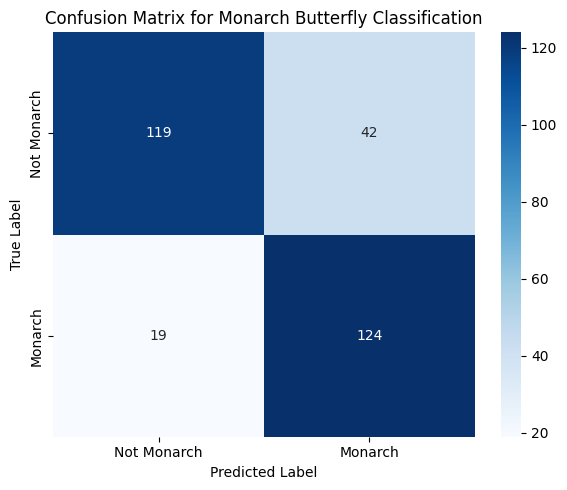

In [ ]:
# 1. Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Define class labels
labels = ['Not Monarch', 'Monarch']

# 3. Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

# 4. Add axis labels and title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Monarch Butterfly Classification')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import os, shutil

# Inputs you already have:
# X_test: np.ndarray of images (N, H, W, C)
# y_test: np.ndarray of labels (N,)
# filenames_test: list/array of file paths aligned 1:1 with X_test  ← keep this from your loader

# 1) Predict
probs = model.predict(X_test, verbose=0).ravel()          # P(monarch)
y_true = np.asarray(y_test).astype(int).ravel()

# 2) Threshold → hard predictions
thr = 0.5
y_pred = (probs >= thr).astype(int)

# 3) Find mistakes
fp_idx = np.where((y_true == 0) & (y_pred == 1))[0]       # predicted monarch, actually non-monarch
fn_idx = np.where((y_true == 1) & (y_pred == 0))[0]       # predicted non-monarch, actually monarch

# 4) Build result frames
filenames = [f"test_image_{i}.jpg" for i in range(len(X_test))]           # ensure array
df_all = pd.DataFrame({
    "filename": filenames,
    "y_true": y_true,
    "prob_monarch": probs,
    "y_pred": y_pred
})

df_fp = df_all.iloc[fp_idx].sort_values("prob_monarch", ascending=False)
df_fn = df_all.iloc[fn_idx].sort_values("prob_monarch", ascending=True)

# 5) Save CSVs
df_all.to_csv("test_predictions.csv", index=False)
df_fp.to_csv("false_positives.csv", index=False)
df_fn.to_csv("false_negatives.csv", index=False)

print(f"FP: {len(df_fp)} | FN: {len(df_fn)}")

# 6) (Optional) copy images for quick visual review
def copy_list(df, dst_root):
    os.makedirs(dst_root, exist_ok=True)
    for src in df["filename"]:
        try:
            shutil.copy2(src, os.path.join(dst_root, os.path.basename(src)))
        except FileNotFoundError:
            # If paths are relative, prepend your dataset root here
            pass

#copy_list(df_fp, "review_false_positives")
copy_list(df_fn, "review_false_negatives")


FP: 44 | FN: 13


❌ Not found: example.jpg


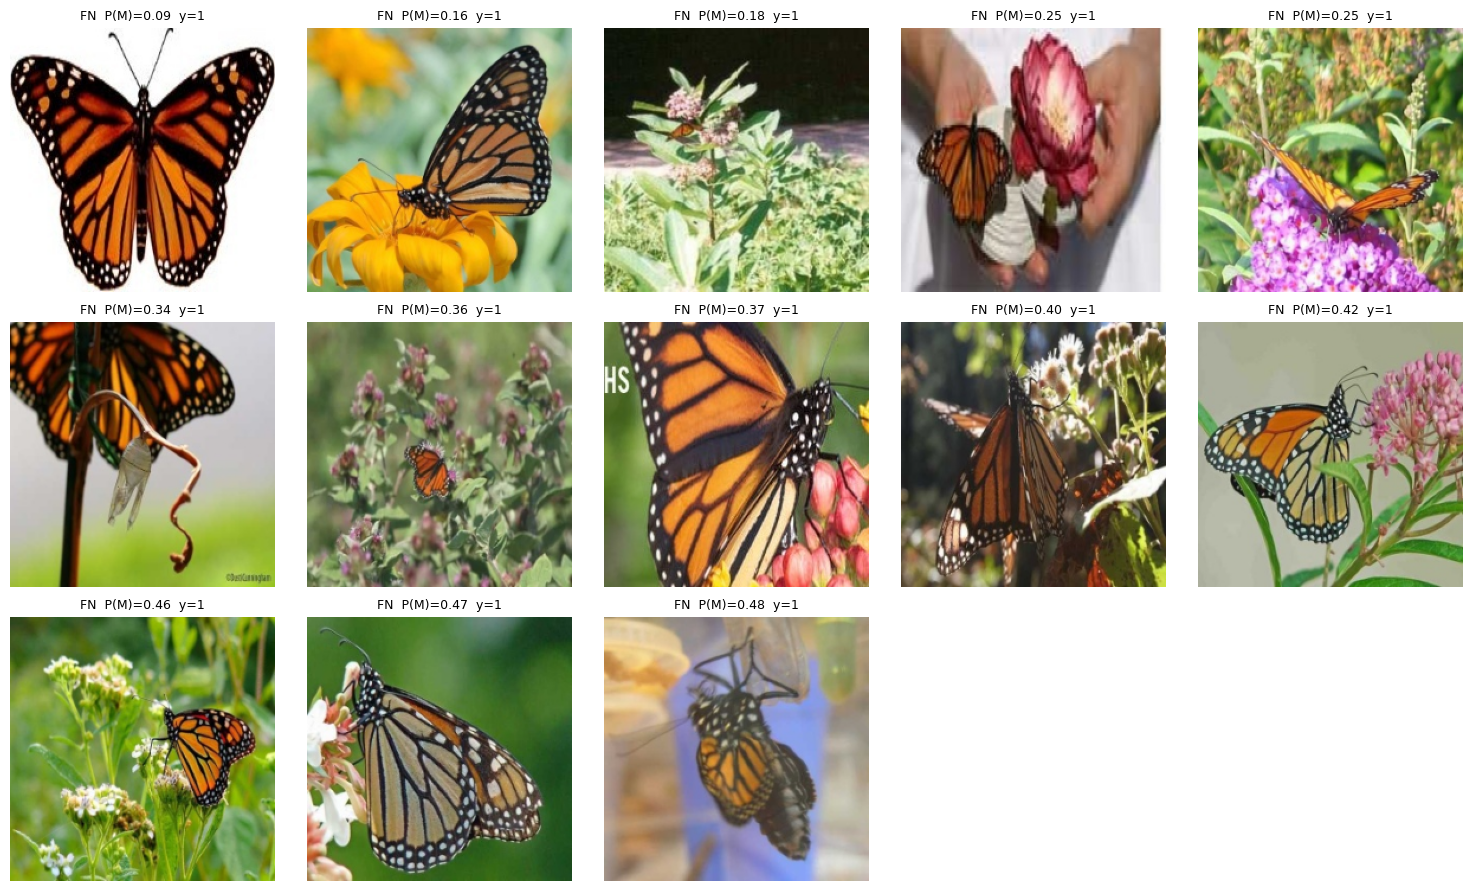

In [ ]:
import os, math
import numpy as np, matplotlib.pyplot as plt, cv2

# ---- Safe single-image read & display ----
def imread_rgb(path):
    if not os.path.exists(path):
        print(f"❌ Not found: {path}")
        return None
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        print(f"⚠️ Could not load: {path}")
        return None
    if img.ndim == 2:                      # grayscale
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.shape[-1] == 4:               # BGRA -> RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)
    else:                                  # BGR -> RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

example_path = "example.jpg"  # <- update to your real path
img_rgb = imread_rgb(example_path)
if img_rgb is not None:
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

# ---- Safer gallery for arrays ----
def show_images_from_array(images, indices, titles=None, cols=5, max_show=20, assume_rgb=True):
    """
    images: np.ndarray of shape (N, H, W, C) or (N, H, W)
    indices: list/array of indices to show
    titles: optional list of titles, aligned with indices
    assume_rgb: set False if your 'images' are BGR (e.g., loaded via cv2 without conversion)
    """
    n = min(len(indices), max_show)
    rows = math.ceil(n / cols)
    plt.figure(figsize=(3*cols, 3*rows))

    for i, idx in enumerate(indices[:n]):
        img = np.asarray(images[idx])

        # Channel handling
        if img.ndim == 2:
            vis = img
            cmap = 'gray'
        else:
            if not assume_rgb:
                img = img[..., ::-1]  # BGR->RGB
            cmap = None
            # dtype/range guard
            if img.dtype != np.uint8:
                vis = np.clip(img, 0, 1) if img.max() <= 1.0 else np.clip(img, 0, 255).astype(np.uint8)
            else:
                vis = img

        plt.subplot(rows, cols, i+1)
        plt.imshow(vis, cmap=cmap)
        plt.axis('off')
        if titles is not None and i < len(titles):
            plt.title(titles[i], fontsize=9)

    plt.tight_layout()
    plt.show()

# ---- Your existing indices/titles ----
# Build titles and show
fp_sorted = fp_idx[np.argsort(probs[fp_idx])[::-1]]
fn_sorted = fn_idx[np.argsort(probs[fn_idx])]

fp_titles = [f"FP  P(M)={probs[i]:.2f}  y=0" for i in fp_sorted]
fn_titles = [f"FN  P(M)={probs[i]:.2f}  y=1" for i in fn_sorted]

# Show examples
show_images_from_array(X_test, fn_sorted, fn_titles, cols=5, max_show=15, assume_rgb=True)
# show_images_from_array(X_test, fp_sorted, fp_titles, cols=5, max_show=15, assume_rgb=True)



In [ ]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred, pos_label=1)
metrics.auc(fpr, tpr)

NameError: name 'metrics' is not defined

In [ ]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='example estimator')
display.plot()
plt.show()

It looks like your Colab session is crashing because you're loading all the images into memory at once, which consumes a lot of RAM.

A common and effective way to handle large image datasets in deep learning is to use **data generators**. Data generators load images in batches during the training process, rather than loading the entire dataset into memory at once. This significantly reduces memory usage and allows you to work with datasets that are too large to fit into RAM.

Here's how you can implement a data generator using `ImageDataGenerator` from Keras:

1.  **Create an `ImageDataGenerator` instance**: You can also include data augmentation parameters here if you want to perform augmentations on the fly.
2.  **Use the `flow_from_directory` method**: This method takes the directory path of your images and generates batches of augmented data.

This approach will help prevent your session from crashing due to memory issues.

In [ ]:
# Create ImageDataGenerators for training and testing
# You can add data augmentation parameters here if needed
train_datagen = ImageDataGenerator(rescale=1./255) # Rescaling is already done in your loading code, but included here for completeness if you change your approach
test_datagen = ImageDataGenerator(rescale=1./255) # Rescaling is already done in your loading code, but included here for completeness if you change your approach

# Define the directory containing your training images
train_dir = '/content/drive/MyDrive/archive/train' # Assuming your training images are in this directory

# Define the directory containing your testing images
# You might need to create a separate directory for your test set if it's not already structured this way
test_dir = '/content/drive/MyDrive/archive/test' # Replace with your actual test directory path

# Create the train and test generators
# flow_from_dataframe is useful when your labels are in a pandas DataFrame
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df.iloc[3000:], # Using the same slice as your original loading code
    directory=train_dir,
    x_col='filename',
    y_col='label_bin',
    target_size=(224, 224), # Match your image size
    batch_size=32, # Adjust batch size as needed
    class_mode='binary' # Use 'binary' for binary classification
)

# For the test set, you'll need a DataFrame or a directory structure.
# Assuming you have a similar structure for test data:
# Create a DataFrame for test data (replace with your actual test data loading)
test_csv_file = '/content/drive/MyDrive/archive/Testing_set.csv' # Replace with your actual test CSV
test_df = pd.read_csv(test_csv_file) # Load your test CSV
test_df['label_bin'] = (test_df['label'].str.upper() == 'MONARCH').astype(int) # Create binary label column

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory='/content/drive/MyDrive/archive/test', # Replace with your actual test image directory
    x_col='filename',
    y_col='label_bin',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False # Set to False for evaluation
)

TypeError: If class_mode="binary", y_col="label_bin" column values must be strings.

In [ ]:
import os
import re
import uuid
import shutil
import pandas as pd
from pathlib import Path

# ====== INPUTS (update only if your paths differ) ======
csv_file = '/content/drive/MyDrive/archive/Training_set.csv'   # existing labels
image_dir = '/content/drive/MyDrive/archive/train'             # existing images root
new_monarch_dir = '/content/drive/MyDrive/archive/new_monarch_butterfly_data_265pxl/data/train/monarch'  # new monarch images

# ====== OUTPUT PROJECT STRUCTURE ======
project_root = '/content/drive/MyDrive/AjayButterflyProject'
images_out_root = f'{project_root}/images/train'
labels_out_file = f'{project_root}/labels.csv'

# ====== UTILITIES ======
def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)
    return p

def copytree_merge(src: str, dst: str):
    """Copy folder content into dst (merging if exists)."""
    ensure_dir(dst)
    for root, dirs, files in os.walk(src):
        rel = os.path.relpath(root, src)
        dst_dir = os.path.join(dst, rel) if rel != '.' else dst
        ensure_dir(dst_dir)
        for d in dirs:
            ensure_dir(os.path.join(dst_dir, d))
        for f in files:
            src_f = os.path.join(root, f)
            dst_f = os.path.join(dst_dir, f)
            # Avoid overwriting identical files; if conflict, keep original
            if not os.path.exists(dst_f):
                shutil.copy2(src_f, dst_f)

def guess_colname(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    # try case-insensitive match
    lower_map = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None

def infer_monarch_label(df, filename_col, label_col):
    """
    Try to infer monarch's label value (string or int) from existing data.
    Heuristics:
    - If label is string and has 'MONARCH' (any case) among uniques -> use that.
    - If label is int, detect which int pairs with filenames containing 'MONARCH' folder.
    - Otherwise, default to 'MONARCH' for string labels or 1 for numeric labels.
    """
    uniques = df[label_col].unique()
    # String case
    if any(isinstance(x, str) for x in uniques):
        # Exact or case-insensitive match
        for u in uniques:
            if isinstance(u, str) and u.strip().lower() == 'monarch':
                return u
        # Heuristic via filename folder names
        for u in uniques:
            if isinstance(u, str):
                sample = df[(df[label_col] == u) & (df[filename_col].astype(str).str.contains('monarch', case=False, na=False))]
                if len(sample) > 0:
                    return u
        return 'MONARCH'
    else:
        # Numeric case: try to find which int correlates with MONARCH filenames
        candidate = None
        for u in uniques:
            sample = df[(df[label_col] == u) & (df[filename_col].astype(str).str.contains('monarch', case=False, na=False))]
            if len(sample) > 0:
                candidate = u
                break
        return candidate if candidate is not None else 1

def make_unique_name(target_dir: str, base_name: str):
    """
    Ensure filename uniqueness inside target_dir.
    Keeps extension; if conflict, appends a short uuid suffix.
    """
    base = Path(base_name).stem
    ext = Path(base_name).suffix
    candidate = base + ext
    full = os.path.join(target_dir, candidate)
    if not os.path.exists(full):
        return candidate
    # Add short UUID
    candidate = f"{base}_{uuid.uuid4().hex[:8]}{ext}"
    return candidate

# ====== 1) Read existing CSV ======
df = pd.read_csv(csv_file)
filename_col = guess_colname(df, ['filename', 'file', 'image', 'img', 'path', 'filepath'])
label_col = guess_colname(df, ['label', 'class', 'species', 'target', 'category', 'is_monarch'])

if filename_col is None or label_col is None:
    raise ValueError(
        f"Could not find filename/label columns in CSV. "
        f"Detected columns: {list(df.columns)}. "
        f"Try renaming your columns to include common names like 'filename' and 'label'."
    )

# ====== 2) Create project folders & copy OLD images ======
ensure_dir(project_root)
copytree_merge(image_dir, images_out_root)

# Establish target MONARCH class folder name based on existing structure
# Prefer a clear canonical subfolder name:
monarch_subfolder_name = 'MONARCH'
monarch_target_dir = os.path.join(images_out_root, monarch_subfolder_name)
ensure_dir(monarch_target_dir)

# If your existing dataset already uses a different case (e.g., 'monarch'), keep the extra folder too.
# We’ll still copy all new images into MONARCH for consistency.

# ====== 3) Copy NEW MONARCH images into the MONARCH subfolder ======
new_files = []
for f in sorted(os.listdir(new_monarch_dir)):
    src = os.path.join(new_monarch_dir, f)
    if not os.path.isfile(src):
        continue
    # Only image-like extensions
    if not re.search(r'\.(jpg|jpeg|png|bmp|tif|tiff|webp)$', f, flags=re.IGNORECASE):
        continue
    unique_name = make_unique_name(monarch_target_dir, f)
    dst = os.path.join(monarch_target_dir, unique_name)
    shutil.copy2(src, dst)
    # Record relative path like in old CSV (try to mirror style: if old CSV stores only filenames, keep only filename)
    # Heuristic: if old CSV values look like just 'Image_4.jpg', we’ll keep only filename; otherwise store relative path from images root.
    sample_val = str(df[filename_col].iloc[0])
    if '/' in sample_val or '\\' in sample_val:
        rel_value = os.path.relpath(dst, images_out_root)  # e.g. 'MONARCH/Image_123.jpg'
    else:
        rel_value = unique_name  # just the file name
    new_files.append(rel_value)

# ====== 4) Build new rows for labels ======
monarch_label_value = infer_monarch_label(df, filename_col, label_col)

new_rows = pd.DataFrame({
    filename_col: new_files,
    label_col: [monarch_label_value] * len(new_files),
})

# ====== 5) Combine and SAVE new labels ======
df_out = pd.concat([df.copy(), new_rows], ignore_index=True)

# (Optional) sort by filename to keep things neat
if filename_col in df_out.columns:
    df_out = df_out.sort_values(by=filename_col, key=lambda s: s.astype(str).str.lower()).reset_index(drop=True)

# Save
df_out.to_csv(labels_out_file, index=False)

# ====== 6) Summary ======
orig_counts = df[label_col].value_counts(dropna=False).to_dict()
new_counts = df_out[label_col].value_counts(dropna=False).to_dict()

print("✅ Project created:", project_root)
print("📁 Images copied to:", images_out_root)
print("📝 New labels saved to:", labels_out_file)
print("\n— Summary —")
print(f"Original rows: {len(df)}")
print(f"New monarch images added: {len(new_files)}")
print(f"Final rows: {len(df_out)}")
print("\nOriginal label distribution:", orig_counts)
print("New label distribution:", new_counts)
print("\nSample of appended rows:")
print(new_rows.head())
